##We have selected Gallstone dataset from :
https://archive.ics.uci.edu/dataset/1150/gallstone-1

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Logistic Regression using Gradient Descent

### Steepest descent from scratch

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder

In [ ]:
# Load the dataset
data = pd.read_csv('/content/Gallstone.csv')

In [ ]:
display(data)
data.shape

,Gallstone Status,Age,Gender,Comorbidity,Coronary Artery Disease (CAD),Hypothyroidism,Hyperlipidemia,Diabetes Mellitus (DM),Height,Weight,...,High Density Lipoprotein (HDL),Triglyceride,Aspartat Aminotransferaz (AST),Alanin Aminotransferaz (ALT),Alkaline Phosphatase (ALP),Creatinine,Glomerular Filtration Rate (GFR),C-Reactive Protein (CRP),Hemoglobin (HGB),Vitamin D
0,0,50,0,0,0,0,0,0,185,92.8,...,40.0,134.0,20.0,22.0,87.0,0.82,112.47,0.0,16.0,33.0
1,0,47,0,1,0,0,0,0,176,94.5,...,43.0,103.0,14.0,13.0,46.0,0.87,107.10,0.0,14.4,25.0
2,0,61,0,0,0,0,0,0,171,91.1,...,43.0,69.0,18.0,14.0,66.0,1.25,65.51,0.0,16.2,30.2
3,0,41,0,0,0,0,0,0,168,67.7,...,59.0,53.0,20.0,12.0,34.0,1.02,94.10,0.0,15.4,35.4
4,0,42,0,0,0,0,0,0,178,89.6,...,30.0,326.0,27.0,54.0,71.0,0.82,112.47,0.0,16.8,40.6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
314,1,49,0,0,0,0,0,0,178,88.8,...,55.0,81.0,28.0,50.0,90.0,0.98,94.50,6.2,16.5,8.3
315,1,31,1,0,0,0,0,0,157,53.4,...,58.0,64.0,24.0,16.0,38.0,0.50,128.50,0.0,12.5,24.0
316,1,58,0,0,0,0,0,0,172,96.6,...,45.0,168.0,21.0,27.0,94.0,1.04,83.23,0.0,15.4,15.7
317,1,37,1,0,0,0,0,0,177,88.4,...,33.0,253.0,40.0,22.0,115.0,1.01,98.23,0.4,16.0,33.3


(319, 39)

In [ ]:
data[	'Gallstone Status']=[1 if i==0 else 0 for i in data[	'Gallstone Status']]

In [ ]:
data.iloc[314]

,314
Gallstone Status,0.00
Age,49.00
Gender,0.00
Comorbidity,0.00
Coronary Artery Disease (CAD),0.00
Hypothyroidism,0.00
Hyperlipidemia,0.00
Diabetes Mellitus (DM),0.00
Height,178.00
Weight,88.80


In [ ]:
# Display number of missing values per column
print("Missing values in each column:")
print(data.isnull().sum())

Missing values in each column:
Gallstone Status                                  0
Age                                               0
Gender                                            0
Comorbidity                                       0
Coronary Artery Disease (CAD)                     0
Hypothyroidism                                    0
Hyperlipidemia                                    0
Diabetes Mellitus (DM)                            0
Height                                            0
Weight                                            0
Body Mass Index (BMI)                             0
Total Body Water (TBW)                            0
Extracellular Water (ECW)                         0
Intracellular Water (ICW)                         0
Extracellular Fluid/Total Body Water (ECF/TBW)    0
Total Body Fat Ratio (TBFR) (%)                   0
Lean Mass (LM) (%)                                0
Body Protein Content (Protein) (%)                0
Visceral Fat Rating (VFR)        

No Null value detected

In [ ]:

X = data.drop('Gallstone Status', axis=1)
y = data['Gallstone Status']

# Encoding categorical variables:
X = pd.get_dummies(X, drop_first=True)
if y.dtype == 'object':
    y = LabelEncoder().fit_transform(y)


In [ ]:
# Train-Test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.fit_transform(X_test)

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((255, 38), (64, 38), (255,), (64,))

In [ ]:
# Fit Decision Tree
tree = DecisionTreeClassifier(random_state=42)
tree.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [ ]:
feature_df_for_names = data.drop('Gallstone Status', axis=1)
feature_df_for_names = pd.get_dummies(feature_df_for_names, drop_first=True)
feature_names = feature_df_for_names.columns


In [ ]:
# Extracting and sorting feature importances
importances = pd.DataFrame({'feature': feature_names, 'feature_importances': tree.feature_importances_ })
importances = importances.sort_values(by='feature_importances', ascending=False)
print(importances)

                                           feature  feature_importances
35                        C-Reactive Protein (CRP)             0.236082
37                                       Vitamin D             0.164432
30                  Aspartat Aminotransferaz (AST)             0.075873
8                                           Weight             0.047060
22                         Visceral Fat Area (VFA)             0.046933
21                         Total Fat Content (TFC)             0.045491
34                Glomerular Filtration Rate (GFR)             0.042092
5                                   Hyperlipidemia             0.039829
27                   Low Density Lipoprotein (LDL)             0.029855
33                                      Creatinine             0.029008
32                      Alkaline Phosphatase (ALP)             0.027992
20                                     Obesity (%)             0.025309
10                          Total Body Water (TBW)             0

<Figure size 1500x1000 with 0 Axes>

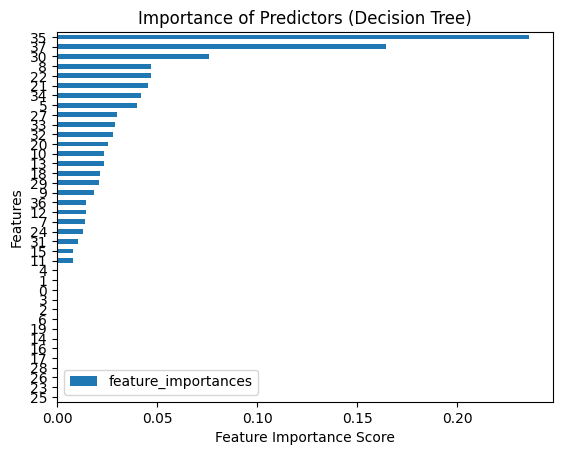

In [ ]:
plt.figure(figsize=(15, 10))
importances.plot(kind='barh')
plt.xlabel('Feature Importance Score')
plt.ylabel('Features')
plt.title('Importance of Predictors (Decision Tree)')
plt.gca().invert_yaxis()
plt.show()


In [ ]:
# We are selecting top predictors on the basis of their feature importance score using a simple threshold of 0.01.

k = 0.01 # Influential threshold
top_features = (
    importances.loc[importances['feature_importances'] >= k]
    .sort_values('feature_importances', ascending=False)['feature']
    .tolist()
)
# Display top predictors
print("Top Influential Predictors:")
print(top_features)

Top Influential Predictors:
['C-Reactive Protein (CRP)', 'Vitamin D', 'Aspartat Aminotransferaz (AST)', 'Weight', 'Visceral Fat Area (VFA)', 'Total Fat Content (TFC)', 'Glomerular Filtration Rate (GFR)', 'Hyperlipidemia', 'Low Density Lipoprotein (LDL)', 'Creatinine', 'Alkaline Phosphatase (ALP)', 'Obesity (%)', 'Total Body Water (TBW)', 'Extracellular Fluid/Total Body Water (ECF/TBW)', 'Bone Mass (BM)', 'Triglyceride', 'Body Mass Index (BMI)', 'Hemoglobin (HGB)', 'Intracellular Water (ICW)', 'Height', 'Hepatic Fat Accumulation (HFA)', 'Alanin Aminotransferaz (ALT)']


In [ ]:
# Create a mapping from feature name to its original index for efficient lookup.
feature_name_to_index = {name: i for i, name in enumerate(feature_names)}

# Get the integer indices for the top_features.
top_feature_indices = [feature_name_to_index[f] for f in top_features]

X_train = X_train[:, top_feature_indices]
X_test = X_test[:, top_feature_indices]

# Print shapes to confirm the change.
print(f"X_train shape after selecting top features: {X_train.shape}")
print(f"X_test shape after selecting top features: {X_test.shape}")

X_train shape after selecting top features: (255, 22)
X_test shape after selecting top features: (64, 22)


In [ ]:
# We define the multiple logit the function using the sigmoid function.
def sigmoid(z):

    return 1 / (1 + np.exp(-z))


# 2. Cost Function of a Multiple Logistic Regression model.
def compute_cost(X, y, w, b):

    n = X.shape[0]
    z = np.dot(X, w) + b
    y_pred = sigmoid(z)
    #We are minimizing the negative of the log-likelihood function of the Multiple Logit.

    cost = -(1/n) * np.sum(y*np.log(y_pred) + (1 - y)*np.log(1 - y_pred))
    return cost


# 3. Steepest Descent Algorithm
def steepest_descent(X, y, learning_rate=0.01, iterations=1000):

    n_samples, n_features = X.shape
    # Converting y to a NumPy array and reshaping it to a column vector.
    if isinstance(y, pd.Series):
        y = y.to_numpy().reshape(-1, 1)
    else:
        y = y.reshape(-1, 1)

    # Initialize parameters
    w = np.zeros((n_features, 1))
    b = 0.0
    cost_list = []

    for i in range(iterations):

        z = np.dot(X, w) + b
        y_pred = sigmoid(z)

        # Computing gradients
        dw = (1/n_samples) * np.dot(X.T, (y_pred - y))
        db = (1/n_samples) * np.sum(y_pred - y)

        # Updating the parameters
        w -= learning_rate * dw
        b -= learning_rate * db

        # Compute and store cost
        cost = compute_cost(X, y, w, b)
        cost_list.append(cost)

        # Print progress
        if i % 100 == 0:
            print(f"Iteration {i:4d} | Cost = {cost:.6f}")

    return w, b, cost_list


# 4. Prediction Function
def predict(X, w, b):

    z = np.dot(X, w) + b
    pred_prob = sigmoid(z)
    y_pred = np.where(pred_prob >= np.mean(pred_prob), 1, 0)
    return y_pred.flatten()
    #We are choosing the mean of the predicted probabilities as the threshold.


# 5. Accuracy Function
def calculate_accuracy(y_true, y_pred):
      return accuracy_score(y_true,y_pred)

In [ ]:
iter = 3000
lrate = 0.1

In [ ]:
from sklearn.metrics import accuracy_score

Iteration    0 | Cost = 0.680943
Iteration  100 | Cost = 0.483247
Iteration  200 | Cost = 0.461414
Iteration  300 | Cost = 0.451662
Iteration  400 | Cost = 0.445700
Iteration  500 | Cost = 0.441536
Iteration  600 | Cost = 0.438421
Iteration  700 | Cost = 0.435995
Iteration  800 | Cost = 0.434057
Iteration  900 | Cost = 0.432483
Iteration 1000 | Cost = 0.431188
Iteration 1100 | Cost = 0.430112
Iteration 1200 | Cost = 0.429212
Iteration 1300 | Cost = 0.428453
Iteration 1400 | Cost = 0.427809
Iteration 1500 | Cost = 0.427260
Iteration 1600 | Cost = 0.426789
Iteration 1700 | Cost = 0.426384
Iteration 1800 | Cost = 0.426035
Iteration 1900 | Cost = 0.425731
Iteration 2000 | Cost = 0.425467
Iteration 2100 | Cost = 0.425235
Iteration 2200 | Cost = 0.425033
Iteration 2300 | Cost = 0.424854
Iteration 2400 | Cost = 0.424697
Iteration 2500 | Cost = 0.424558
Iteration 2600 | Cost = 0.424434
Iteration 2700 | Cost = 0.424324
Iteration 2800 | Cost = 0.424225
Iteration 2900 | Cost = 0.424137

Test Accu

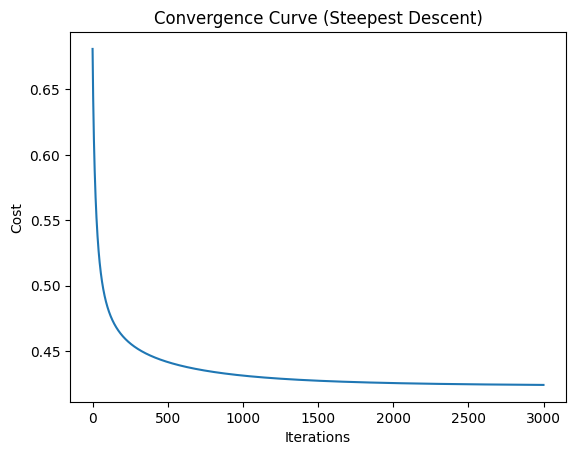

In [ ]:
# Train model using steepest descent
w, b, cost_list = steepest_descent(X_train, y_train, learning_rate=lrate, iterations=iter)

# Predict on test data
y_pred = predict(X_test, w, b)

# Evaluate accuracy
acc = calculate_accuracy(y_test, y_pred)
print(f"\nTest Accuracy: {acc:.2f}%")

# Plot cost curve
plt.plot(range(len(cost_list)), cost_list)
plt.xlabel("Iterations")
plt.ylabel("Cost")
plt.title("Convergence Curve (Steepest Descent)")
plt.show()

### Compact code for DecisionTreeClassifier

The Gallstone Dataset:


,Gallstone Status,Age,Gender,Comorbidity,Coronary Artery Disease (CAD),Hypothyroidism,Hyperlipidemia,Diabetes Mellitus (DM),Height,Weight,...,High Density Lipoprotein (HDL),Triglyceride,Aspartat Aminotransferaz (AST),Alanin Aminotransferaz (ALT),Alkaline Phosphatase (ALP),Creatinine,Glomerular Filtration Rate (GFR),C-Reactive Protein (CRP),Hemoglobin (HGB),Vitamin D
0,1,50,0,0,0,0,0,0,185,92.8,...,40.0,134.0,20.0,22.0,87.0,0.82,112.47,0.0,16.0,33.0
1,1,47,0,1,0,0,0,0,176,94.5,...,43.0,103.0,14.0,13.0,46.0,0.87,107.10,0.0,14.4,25.0
2,1,61,0,0,0,0,0,0,171,91.1,...,43.0,69.0,18.0,14.0,66.0,1.25,65.51,0.0,16.2,30.2
3,1,41,0,0,0,0,0,0,168,67.7,...,59.0,53.0,20.0,12.0,34.0,1.02,94.10,0.0,15.4,35.4
4,1,42,0,0,0,0,0,0,178,89.6,...,30.0,326.0,27.0,54.0,71.0,0.82,112.47,0.0,16.8,40.6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
314,0,49,0,0,0,0,0,0,178,88.8,...,55.0,81.0,28.0,50.0,90.0,0.98,94.50,6.2,16.5,8.3
315,0,31,1,0,0,0,0,0,157,53.4,...,58.0,64.0,24.0,16.0,38.0,0.50,128.50,0.0,12.5,24.0
316,0,58,0,0,0,0,0,0,172,96.6,...,45.0,168.0,21.0,27.0,94.0,1.04,83.23,0.0,15.4,15.7
317,0,37,1,0,0,0,0,0,177,88.4,...,33.0,253.0,40.0,22.0,115.0,1.01,98.23,0.4,16.0,33.3


Missing values per column:
Gallstone Status                                  0
Age                                               0
Gender                                            0
Comorbidity                                       0
Coronary Artery Disease (CAD)                     0
Hypothyroidism                                    0
Hyperlipidemia                                    0
Diabetes Mellitus (DM)                            0
Height                                            0
Weight                                            0
Body Mass Index (BMI)                             0
Total Body Water (TBW)                            0
Extracellular Water (ECW)                         0
Intracellular Water (ICW)                         0
Extracellular Fluid/Total Body Water (ECF/TBW)    0
Total Body Fat Ratio (TBFR) (%)                   0
Lean Mass (LM) (%)                                0
Body Protein Content (Protein) (%)                0
Visceral Fat Rating (VFR)            

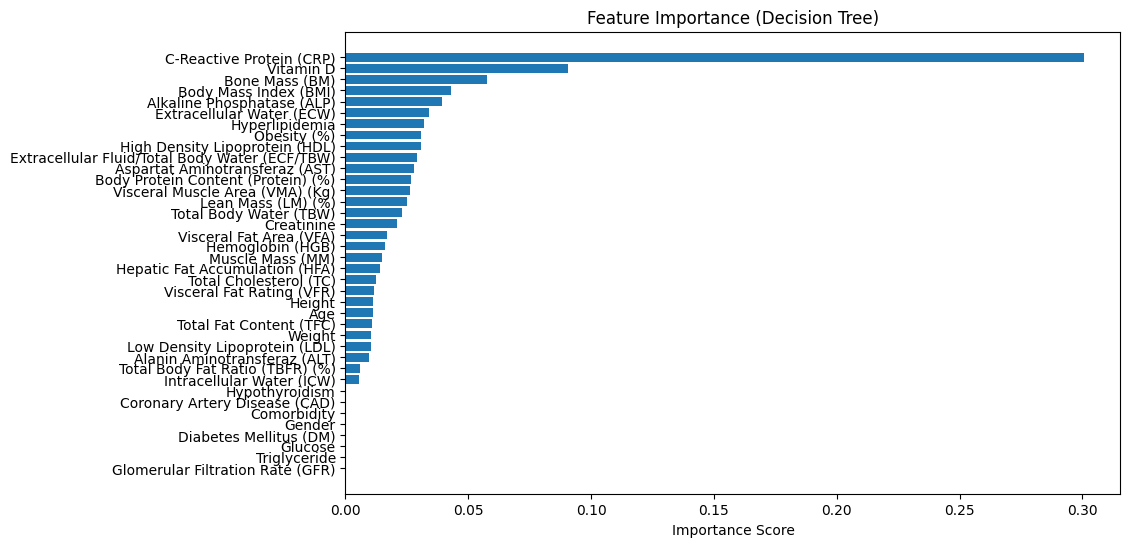


Top Influential Predictors:
['C-Reactive Protein (CRP)', 'Vitamin D', 'Bone Mass (BM)', 'Body Mass Index (BMI)', 'Alkaline Phosphatase (ALP)', 'Extracellular Water (ECW)', 'Hyperlipidemia', 'Obesity (%)', 'High Density Lipoprotein (HDL)', 'Extracellular Fluid/Total Body Water (ECF/TBW)', 'Aspartat Aminotransferaz (AST)', 'Body Protein Content (Protein) (%)', 'Visceral Muscle Area (VMA) (Kg)', 'Lean Mass (LM) (%)', 'Total Body Water (TBW)', 'Creatinine', 'Visceral Fat Area (VFA)', 'Hemoglobin (HGB)', 'Muscle Mass (MM)', 'Hepatic Fat Accumulation (HFA)', 'Total Cholesterol (TC)', 'Visceral Fat Rating (VFR)', 'Height', 'Age', 'Total Fat Content (TFC)', 'Weight', 'Low Density Lipoprotein (LDL)', 'Alanin Aminotransferaz (ALT)', 'Total Body Fat Ratio (TBFR) (%)', 'Intracellular Water (ICW)']
Iteration    0 | Cost = 0.674797
Iteration  100 | Cost = 0.486358
Iteration  200 | Cost = 0.464731
Iteration  300 | Cost = 0.453284
Iteration  400 | Cost = 0.445651
Iteration  500 | Cost = 0.440142
Iter

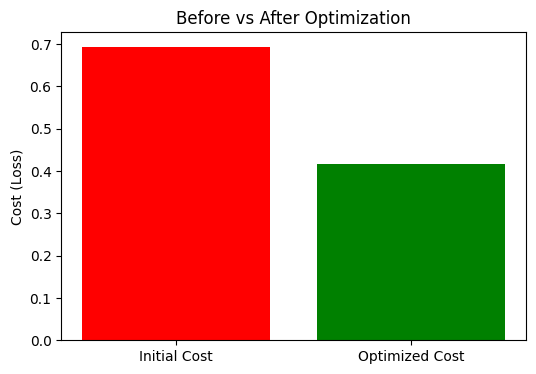


Test Accuracy: 89.06%


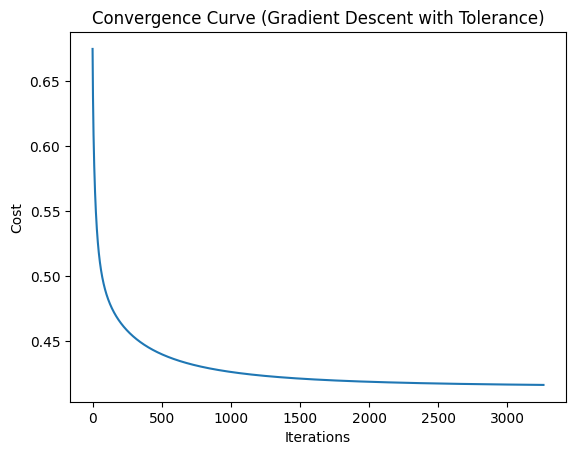

Accuracy: 0.890625


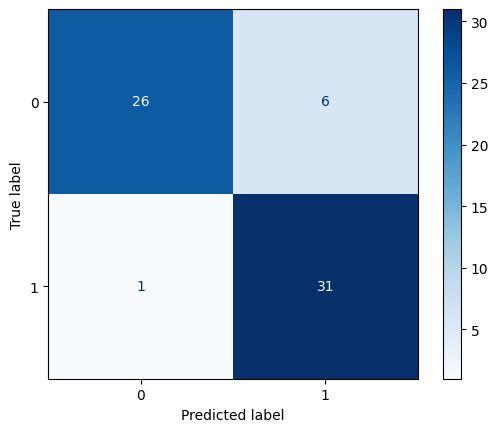

In [ ]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay




# Load and Inspect Data
data = pd.read_csv("/content/Gallstone.csv")
data[	'Gallstone Status']=[1 if i==0 else 0 for i in data[	'Gallstone Status']]

print("The Gallstone Dataset:")
display(data)

print("Missing values per column:")
print(data.isnull().sum())





# Separating Predictors and Target
X = data.drop('Gallstone Status', axis=1)
y = data['Gallstone Status']

# Encoding Categorical variables
X = pd.get_dummies(X, drop_first=True)
if y.dtype == 'object':
    y = LabelEncoder().fit_transform(y)





# Feature Importance (Before Scaling)
tree = DecisionTreeClassifier(random_state=42)
tree.fit(X, y)

importances = pd.DataFrame({
    'feature': X.columns,
    'importance': tree.feature_importances_
}).sort_values(by='importance', ascending=False)

print("\nFeature Importances (Top 10):")
print(importances)

plt.figure(figsize=(10, 6))
plt.barh(importances['feature'], importances['importance'])
plt.gca().invert_yaxis()
plt.title("Feature Importance (Decision Tree)")
plt.xlabel("Importance Score")
plt.show()

# Select top influential predictors by settinga threshold as 0.005.
threshold = 0.005
top_features = importances.query("importance >= @threshold")['feature'].tolist()

print("\nTop Influential Predictors:")
print(top_features)





# Train-Test Split (on selected features)
X = X[top_features]
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42, stratify=y)





# Scale Features (After feature selection)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)





# Multiple Logistic Regression
#We use the sigmoid function to define P(Y=1| given predictors)
def sigmoid(z):

    return 1 / (1 + np.exp(-z))

def compute_cost(X, y, w, b):
    #we have to minimize the negative of the log likelihood function.
    if isinstance(y, pd.Series):
        y = y.to_numpy().reshape(-1, 1)
    else:
        y = y.reshape(-1, 1)

    n = X.shape[0]
    z = np.dot(X, w) + b
    y_pred = sigmoid(z)
    cost = -(1/n) * np.sum(y*np.log(y_pred + 1e-15) + (1 - y)*np.log(1 - y_pred + 1e-15))
    return cost
#We define the steepest descent algorithm.
def steepest_descent(X, y, lr=0.05, iterations=3000, tol=1e-6):

    n, m = X.shape
    if isinstance(y, pd.Series):
        y = y.to_numpy().reshape(-1, 1)
    else:
        y = y.reshape(-1, 1)

    w = np.zeros((m, 1))
    b = 0.0
    cost_list = []

    prev_cost = float('inf')
    for i in range(iterations):
        z = np.dot(X, w) + b
        y_pred = sigmoid(z)

        dw = (1/n) * np.dot(X.T, (y_pred - y))
        db = (1/n) * np.sum(y_pred - y)

        w -= lr * dw
        b -= lr * db

        cost = compute_cost(X, y, w, b)
        cost_list.append(cost)

        # checking whether exceeding tolerance
        if abs(prev_cost - cost) < tol:
            print(f"Converged at iteration {i} | Cost < {tol}")
            break

        prev_cost = cost

        if i % 100 == 0:
            print(f"Iteration {i:4d} | Cost = {cost:.6f}")

    return w, b, cost_list

def predict(X, w, b):

    #We are choosing mean of the predicted probabilities as threshold.
    probs = sigmoid(np.dot(X, w) + b)
    preds = (probs >= np.mean(probs)).astype(int)
    return preds.flatten()

def accuracy(y_true, y_pred):
    from sklearn.metrics import accuracy_score
    return accuracy_score(y_true,y_pred)





# Train Logistic Regression using Gradient Descent
ITER = 10000
LR = 0.1
TOL = 1e-6  # tolerance threshold
# Compute initial cost (before optimization)
n_features = X_train.shape[1]
initial_w = np.zeros((n_features, 1))
initial_b = 0.0
initial_cost = compute_cost(X_train, y_train, initial_w, initial_b)

# Train model with tolerance
w, b, cost_list = steepest_descent(X_train, y_train, lr=LR, iterations=ITER, tol=TOL)

# Compute optimized cost
optimized_cost = cost_list[-1]

# Cost comparison
cost_comparison = pd.DataFrame({
    "Metric": ["Initial Cost", "Optimized Cost", "Cost Reduction"],
    "Value": [initial_cost, optimized_cost, initial_cost - optimized_cost]
})
print("\nCost Comparison:")
print(cost_comparison.to_string(index=False))

# Plot cost comparison
plt.figure(figsize=(6, 4))
plt.bar(["Initial Cost", "Optimized Cost"], [initial_cost, optimized_cost], color=["red", "green"])
plt.title("Before vs After Optimization")
plt.ylabel("Cost (Loss)")
plt.show()





# Evaluate Model
y_pred= predict(X_test, w, b)
acc = accuracy(y_test, y_pred)
print(f"\nTest Accuracy: {acc*100:.2f}%")

# Plot convergence curve
plt.plot(range(len(cost_list)), cost_list)
plt.xlabel("Iterations")
plt.ylabel("Cost")
plt.title("Convergence Curve (Gradient Descent with Tolerance)")
plt.show()


cm = confusion_matrix(y_test, y_pred, labels=tree.classes_)
disp = ConfusionMatrixDisplay(cm, display_labels=tree.classes_)
disp.plot(cmap=plt.cm.Blues)
from sklearn.metrics import accuracy_score
accuracy_score = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy_score)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


# Load data (adapt your path)
data = pd.read_csv("/content/drive/MyDrive/Gallstone.csv")
print("The Gallstone Dataset:")
display(data)
print("Missing values per column:")
print(data.isnull().sum())


# Separate predictors and target
X = data.drop('Gallstone Status', axis=1)
y = data['Gallstone Status']

# Encode categorical variables
X = pd.get_dummies(X, drop_first=True)
if y.dtype == 'object':
    y = LabelEncoder().fit_transform(y)


# Feature Importance using Decision Tree (before scaling)
tree = DecisionTreeClassifier(random_state=42)
tree.fit(X, y)
importances = pd.DataFrame({'feature': X.columns, 'importance': tree.feature_importances_}).sort_values(by='importance', ascending=False)
print("\nFeature Importances (Top 10):")
print(importances)
plt.figure(figsize=(10, 6))
plt.barh(importances['feature'], importances['importance'])
plt.gca().invert_yaxis()
plt.title("Feature Importance (Decision Tree)")
plt.xlabel("Importance Score")
plt.show()

# Select top influential features by threshold
threshold = 0.005
top_features = importances.query("importance >= @threshold")['feature'].tolist()
print("\nTop Influential Predictors:")
print(top_features)

# Train-test split
X = X[top_features]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Scale features after feature selection
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


# Sigmoid function
def sigmoid(z):
    return 1 / (1 + np.exp(-z))


# Negative log-likelihood cost function
def compute_cost(X, y, w, b):
    if isinstance(y, pd.Series):
        y = y.to_numpy().reshape(-1, 1)
    else:
        y = y.reshape(-1, 1)
    n = X.shape[0]
    z = np.dot(X, w) + b
    y_pred = sigmoid(z)
    cost = -(1/n) * np.sum(y*np.log(y_pred + 1e-15) + (1 - y)*np.log(1 - y_pred + 1e-15))
    return cost


# Backtracking line search for adaptive alpha
def backtracking_line_search(X, y, w, b, dw, db, grad_norm_sq, alpha=0.1, beta=0.8, c=1e-4):
    cost_current = compute_cost(X, y, w, b)
    while True:
        w_new = w - alpha * dw
        b_new = b - alpha * db
        cost_new = compute_cost(X, y, w_new, b_new)
        if cost_new <= cost_current - c * alpha * grad_norm_sq:
            return alpha
        alpha *= beta
        if alpha < 1e-8:  # Avoid too small steps
            return alpha


# Steepest descent with dynamic alpha (backtracking line search)
def steepest_descent(X, y, iterations=3000, tol=1e-6):
    n, m = X.shape
    if isinstance(y, pd.Series):
        y = y.to_numpy().reshape(-1, 1)
    else:
        y = y.reshape(-1, 1)
    w = np.zeros((m, 1))
    b = 0.0
    cost_list = []
    prev_cost = float('inf')
    for i in range(iterations):
        z = np.dot(X, w) + b
        y_pred = sigmoid(z)
        dw = (1/n) * np.dot(X.T, (y_pred - y))
        db = (1/n) * np.sum(y_pred - y)
        grad_norm_sq = np.sum(dw**2) + db**2
        # Get adaptive step size alpha
        alpha = backtracking_line_search(X, y, w, b, dw, db, grad_norm_sq)
        # Update parameters with adaptive step size
        w -= alpha * dw
        b -= alpha * db
        cost = compute_cost(X, y, w, b)
        cost_list.append(cost)
        if abs(prev_cost - cost) < tol:
            print(f"Converged at iteration {i} | Cost change < {tol}")
            break
        prev_cost = cost
        if i % 100 == 0:
            print(f"Iteration {i:4d} | Cost = {cost:.6f} | Alpha = {alpha:.6f}")
    return w, b, cost_list


# Prediction function using mean predicted probability threshold
def predict(X, w, b):
    probs = sigmoid(np.dot(X, w) + b)
    preds = (probs >= np.median(probs)).astype(int)
    return preds.flatten()


# Accuracy evaluation
def accuracy(y_true, y_pred):
    from sklearn.metrics import accuracy_score
    return accuracy_score(y_true, y_pred)


# Train the model
ITER = 10000
TOL = 1e-6

initial_w = np.zeros((X_train.shape[1], 1))
initial_b = 0.0
initial_cost = compute_cost(X_train, y_train, initial_w, initial_b)

w, b, cost_list = steepest_descent(X_train, y_train, iterations=ITER, tol=TOL)

optimized_cost = cost_list[-1]

print("\nCost Comparison:")
import pandas as pd
cost_comparison = pd.DataFrame({
    "Metric": ["Initial Cost", "Optimized Cost", "Cost Reduction"],
    "Value": [initial_cost, optimized_cost, initial_cost - optimized_cost]
})
print(cost_comparison.to_string(index=False))

plt.figure(figsize=(6, 4))
plt.bar(["Initial Cost", "Optimized Cost"], [initial_cost, optimized_cost], color=["red", "green"])
plt.title("Before vs After Optimization")
plt.ylabel("Cost (Loss)")
plt.show()

# Evaluate model on test data
y_pred = predict(X_test, w, b)
acc = accuracy(y_test, y_pred)
print(f"\nTest Accuracy: {acc*100:.2f}%")

plt.plot(range(len(cost_list)), cost_list)
plt.xlabel("Iterations")
plt.ylabel("Cost")
plt.title("Convergence Curve (Gradient Descent with Backtracking Line Search)")
plt.show()

cm = confusion_matrix(y_test, y_pred, labels=tree.classes_)
disp = ConfusionMatrixDisplay(cm, display_labels=tree.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.show()

print("Test Accuracy:", acc)


In [ ]:
print(w,b)

## Logistic Regression using bfgs

### Compact code for DecisionTreeClassifier

The Gallstone Dataset:


,Gallstone Status,Age,Gender,Comorbidity,Coronary Artery Disease (CAD),Hypothyroidism,Hyperlipidemia,Diabetes Mellitus (DM),Height,Weight,...,High Density Lipoprotein (HDL),Triglyceride,Aspartat Aminotransferaz (AST),Alanin Aminotransferaz (ALT),Alkaline Phosphatase (ALP),Creatinine,Glomerular Filtration Rate (GFR),C-Reactive Protein (CRP),Hemoglobin (HGB),Vitamin D
0,1,50,0,0,0,0,0,0,185,92.8,...,40.0,134.0,20.0,22.0,87.0,0.82,112.47,0.0,16.0,33.0
1,1,47,0,1,0,0,0,0,176,94.5,...,43.0,103.0,14.0,13.0,46.0,0.87,107.10,0.0,14.4,25.0
2,1,61,0,0,0,0,0,0,171,91.1,...,43.0,69.0,18.0,14.0,66.0,1.25,65.51,0.0,16.2,30.2
3,1,41,0,0,0,0,0,0,168,67.7,...,59.0,53.0,20.0,12.0,34.0,1.02,94.10,0.0,15.4,35.4
4,1,42,0,0,0,0,0,0,178,89.6,...,30.0,326.0,27.0,54.0,71.0,0.82,112.47,0.0,16.8,40.6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
314,0,49,0,0,0,0,0,0,178,88.8,...,55.0,81.0,28.0,50.0,90.0,0.98,94.50,6.2,16.5,8.3
315,0,31,1,0,0,0,0,0,157,53.4,...,58.0,64.0,24.0,16.0,38.0,0.50,128.50,0.0,12.5,24.0
316,0,58,0,0,0,0,0,0,172,96.6,...,45.0,168.0,21.0,27.0,94.0,1.04,83.23,0.0,15.4,15.7
317,0,37,1,0,0,0,0,0,177,88.4,...,33.0,253.0,40.0,22.0,115.0,1.01,98.23,0.4,16.0,33.3


Missing values per column:
Gallstone Status                                  0
Age                                               0
Gender                                            0
Comorbidity                                       0
Coronary Artery Disease (CAD)                     0
Hypothyroidism                                    0
Hyperlipidemia                                    0
Diabetes Mellitus (DM)                            0
Height                                            0
Weight                                            0
Body Mass Index (BMI)                             0
Total Body Water (TBW)                            0
Extracellular Water (ECW)                         0
Intracellular Water (ICW)                         0
Extracellular Fluid/Total Body Water (ECF/TBW)    0
Total Body Fat Ratio (TBFR) (%)                   0
Lean Mass (LM) (%)                                0
Body Protein Content (Protein) (%)                0
Visceral Fat Rating (VFR)            

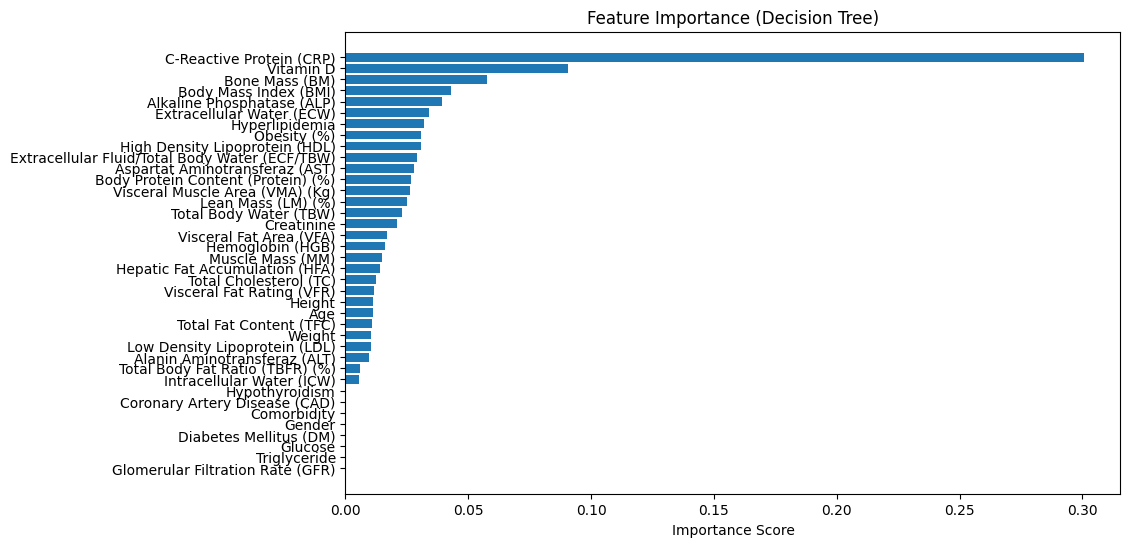


Top Influential Predictors:
['C-Reactive Protein (CRP)', 'Vitamin D', 'Bone Mass (BM)', 'Body Mass Index (BMI)', 'Alkaline Phosphatase (ALP)', 'Extracellular Water (ECW)', 'Hyperlipidemia', 'Obesity (%)', 'High Density Lipoprotein (HDL)', 'Extracellular Fluid/Total Body Water (ECF/TBW)', 'Aspartat Aminotransferaz (AST)', 'Body Protein Content (Protein) (%)', 'Visceral Muscle Area (VMA) (Kg)', 'Lean Mass (LM) (%)', 'Total Body Water (TBW)', 'Creatinine', 'Visceral Fat Area (VFA)', 'Hemoglobin (HGB)', 'Muscle Mass (MM)', 'Hepatic Fat Accumulation (HFA)', 'Total Cholesterol (TC)', 'Visceral Fat Rating (VFR)', 'Height', 'Age', 'Total Fat Content (TFC)', 'Weight', 'Low Density Lipoprotein (LDL)', 'Alanin Aminotransferaz (ALT)', 'Total Body Fat Ratio (TBFR) (%)', 'Intracellular Water (ICW)']

Optimizing Logistic Regression using BFGS...
Optimization terminated successfully.
         Current function value: 0.413844
         Iterations: 182
         Function evaluations: 183
         Gradien

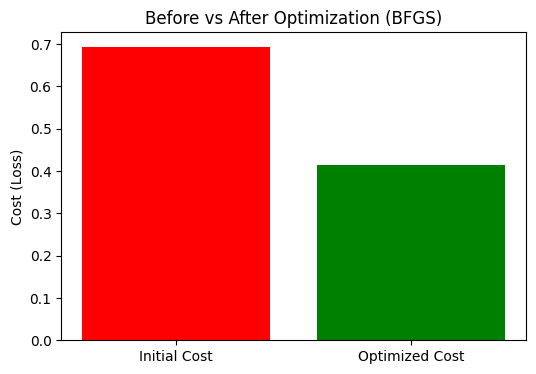


Test Accuracy using BFGS): 85.94%
Accuracy: 0.859375
[[-2.02726472]
 [ 0.81511228]
 [ 1.73337053]
 [ 2.09862599]
 [-0.22043002]
 [ 0.95974977]
 [-2.22751149]
 [-0.08527708]
 [-0.30567883]
 [ 0.38752383]
 [ 1.53641605]
 [ 0.57247282]
 [-0.07911303]
 [-0.86081657]
 [-0.82110812]
 [-0.03835717]
 [-0.18726   ]
 [ 0.49897792]
 [ 0.65916924]
 [-0.27533207]
 [-0.03451608]
 [-0.18252345]
 [ 0.50953878]
 [-0.30985052]
 [ 1.44510182]
 [-2.81833891]
 [ 0.04985351]
 [-1.07797272]
 [-1.82826338]
 [-1.59518926]] -0.6113578464215763


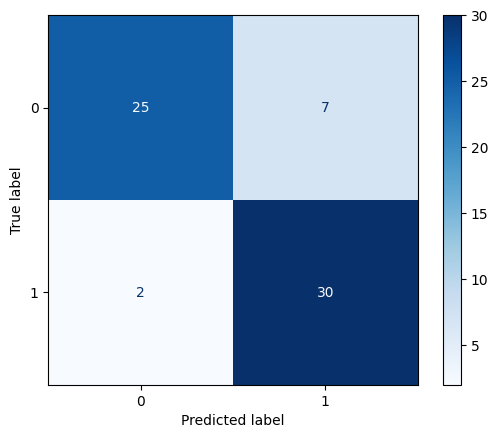

In [ ]:
#Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder
from scipy.optimize import minimize




# Load and Inspect Data
data = pd.read_csv("/content/Gallstone.csv")
data["Gallstone Status"] = [1 if i == 0 else 0 for i in data["Gallstone Status"]]

print("The Gallstone Dataset:")
display(data)

print("Missing values per column:")
print(data.isnull().sum())




# Separate Features and Target
X = data.drop('Gallstone Status', axis=1)
y = data['Gallstone Status']

# Encode categorical variables
X = pd.get_dummies(X, drop_first=True)
if y.dtype == 'object':
    y = LabelEncoder().fit_transform(y)




# Feature Importance using Decision Tree
tree = DecisionTreeClassifier(random_state=42)
tree.fit(X, y)

importances = pd.DataFrame({
    'feature': X.columns,
    'importance': tree.feature_importances_
}).sort_values(by='importance', ascending=False)

print("\nFeature Importances (Top 10):")
print(importances.head(10))

# Plot all feature importances
plt.figure(figsize=(10, 6))
plt.barh(importances['feature'], importances['importance'])
plt.gca().invert_yaxis()
plt.title("Feature Importance (Decision Tree)")
plt.xlabel("Importance Score")
plt.show()

# Select top influential features
threshold = 0.005
top_features = importances.query("importance >= @threshold")['feature'].tolist()
print("\nTop Influential Predictors:")
print(top_features)




# Train-Test Split
X = X[top_features]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Ensure numpy arrays
X_train = np.array(X_train)
X_test = np.array(X_test)
y_train = np.array(y_train)
y_test = np.array(y_test)




#  Scale Features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)




# Multiple Logistic Regression Function (BFGS)
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def cost_function(params, X, y):
   #We are minimizing the negative log-likelihood function.
    m = X.shape[0]
    w = params[:-1].reshape(-1, 1)
    b = params[-1]
    y = y.reshape(-1, 1)
    z = np.dot(X, w) + b
    h = sigmoid(z)
    cost = -(1/m) * np.sum(y*np.log(h) + (1 - y)*np.log(1 - h))
    return cost

def gradient(params, X, y):
    #Gradient of the Cost Function
    m = X.shape[0]
    w = params[:-1].reshape(-1, 1)
    b = params[-1]
    y = y.reshape(-1, 1)
    z = np.dot(X, w) + b
    h = sigmoid(z)
    dw = (1/m) * np.dot(X.T, (h - y))
    db = (1/m) * np.sum(h - y)
    grad = np.concatenate([dw.flatten(), [db]])
    return grad




# BFGS Optimization
initial_params = np.zeros(X_train.shape[1] + 1)

print("\nOptimizing Logistic Regression using BFGS...")
result = minimize(
    fun=cost_function,
    x0=initial_params,
    args=(X_train, y_train),
    method='BFGS',
    jac=gradient,
    options={'disp': True, 'maxiter': 3000,'return_all': True}
)

if not result.success:
    print(f"Optimization did not fully converge: {result}")

optimized_params = result.x
w_opt = optimized_params[:-1].reshape(-1, 1)
b_opt = optimized_params[-1]




# Cost Comparison
initial_cost = cost_function(initial_params, X_train, y_train)
optimized_cost = cost_function(optimized_params, X_train, y_train)

cost_comparison = pd.DataFrame({
    "Metric": ["Initial Cost", "Optimized Cost", "Cost Reduction"],
    "Value": [initial_cost, optimized_cost, initial_cost - optimized_cost]
})

print("\nCost Comparison:")
print(cost_comparison.to_string(index=False))

# Plot cost comparison
plt.figure(figsize=(6, 4))
plt.bar(["Initial Cost", "Optimized Cost"], [initial_cost, optimized_cost], color=["red", "green"])
plt.title("Before vs After Optimization (BFGS)")
plt.ylabel("Cost (Loss)")
plt.show()



from sklearn.metrics import accuracy_score
# Prediction & Evaluation
def predict(X, w, b):
    probs = sigmoid(np.dot(X, w) + b)
    preds = (probs >= np.mean(probs)).astype(int)
    return preds.flatten()

def accuracy(y_true, y_pred):
    return accuracy_score(y_true,y_pred)

y_pred = predict(X_test, w_opt, b_opt)
acc = accuracy(y_test, y_pred)

print(f"\nTest Accuracy using BFGS): {acc*100:.2f}%")

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(y_test, y_pred, labels=tree.classes_)
disp = ConfusionMatrixDisplay(cm, display_labels=tree.classes_)
disp.plot(cmap=plt.cm.Blues)
from sklearn.metrics import accuracy_score
accuracy_score = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy_score)
print(w_opt, b_opt)

In [ ]:
print(w_opt, b_opt)

[[ 2.32142383]
 [-0.81080644]
 [-2.22339016]
 [ 0.41566041]
 [ 0.06701571]
 [-2.3694118 ]
 [ 2.64472881]
 [ 0.09720279]
 [ 0.49090477]
 [ 0.01494412]
 [-1.30693861]
 [-1.14800765]
 [-0.18130242]
 [-1.7402551 ]
 [-0.23196835]
 [-0.05968485]
 [ 1.08505353]
 [-0.38104293]
 [-2.04666453]
 [ 0.14199536]
 [-0.01152614]
 [ 0.21701488]
 [ 0.46533867]
 [ 0.44155847]
 [-7.74419125]
 [ 8.6213477 ]
 [-0.07281267]
 [ 0.5764996 ]
 [-1.300216  ]
 [ 0.39119179]] 0.6766708708486273


In [ ]:
from sklearn.linear_model import SGDClassifier
clf = SGDClassifier(loss='log_loss', max_iter=3000, learning_rate='optimal', tol=1e-6, random_state=42,penalty=None)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

In [ ]:
print("Coefficients (weights):", clf.coef_)
print("Intercept (bias):", clf.intercept_)

Coefficients (weights): [[ 21.96012391  -1.48219144 -26.99790516   4.53715451  -3.45094533
    1.06806336  59.62212828  39.39090242   3.27852461  -2.89427146
  -12.56852743   2.47794092  -0.81389145 -22.03184088  -8.64902489
    2.58369681   8.96288817  -5.54795072  -8.74974164   2.1000944
   -2.1331277    3.63489671   8.66926733   1.89710294 -51.99663981
   16.3983926   -0.14251072   4.17543288   2.71967804  34.98664042]]
Intercept (bias): [17.23330833]


In [ ]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred)

0.78125

BFGS(User Defined)

In [ ]:
import numpy as np

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def cost_function(params, X, y):
    m = X.shape[0]
    w = params[:-1].reshape(-1, 1)
    b = params[-1]
    z = np.dot(X, w) + b
    h = sigmoid(z)
    cost = -(1/m) * np.sum(y*np.log(h + 1e-15) + (1 - y)*np.log(1 - h + 1e-15))
    return cost

def gradient(params, X, y):
    m = X.shape[0]
    w = params[:-1].reshape(-1, 1)
    b = params[-1]
    z = np.dot(X, w) + b
    h = sigmoid(z)
    dw = (1/m) * np.dot(X.T, (h - y))
    db = (1/m) * np.sum(h - y)
    grad = np.concatenate((dw.flatten(), [db]))
    return grad

def backtracking_line_search(params, pk, X, y, grad, alpha=1, rho=0.8, c=1e-4):
    current_cost = cost_function(params, X, y)
    while cost_function(params + alpha * pk, X, y) > current_cost + c * alpha * np.dot(grad, pk):
        alpha *= rho
        if alpha < 1e-8:
            break
    return alpha

def bfgs_logistic_regression(X, y, max_iter=100, tol=1e-6):
    n = X.shape[1] + 1  # number of parameters (weights + bias)
    params = np.zeros(n)  # Initialize parameters to zeros
    Hk = np.eye(n)  # Initial inverse Hessian approx
    y = y.reshape(-1, 1)  # Ensure y is column vector

    for i in range(max_iter):
        grad = gradient(params, X, y).reshape(-1, 1)  # ensure grad shape (n,1)
        pk = -np.dot(Hk, grad)  # search direction (n,1)
        pk = pk.flatten()  # flatten for parameter update

        # Line search to find step size alpha
        alpha = backtracking_line_search(params, pk, X, y, grad.flatten())

        new_params = params + alpha * pk
        new_grad = gradient(new_params, X, y).reshape(-1, 1)

        sk = (new_params - params).reshape(-1, 1)
        yk = new_grad - grad

        if np.dot(yk.T, sk) == 0:  # Avoid division by zero
            print("Division by zero in BFGS update; stopping.")
            break

        rho_k = 1.0 / np.dot(yk.T, sk)

        I = np.eye(n)
        Vk = I - rho_k * np.dot(sk, yk.T)
        Hk = np.dot(Vk, np.dot(Hk, Vk.T)) + rho_k * np.dot(sk, sk.T)

        params = new_params

        cost = cost_function(params, X, y)
        print(f"Iteration {i+1}: Cost={cost:.6f}")

        if np.linalg.norm(new_grad) < tol:
            print("Converged.")
            break

    w_opt = params[:-1].reshape(-1, 1)
    b_opt = params[-1]
    return w_opt, b_opt

# Example usage:
# Assuming X_train and y_train are your preprocessed features (numpy array) and labels (numpy array)
# w_opt, b_opt = bfgs_logistic_regression(X_train, y_train)


In [ ]:
bfgs_logistic_regression(X=X_train, y=y_train, max_iter=100, tol=1e-6)


Iteration 1: Cost=0.609644
Iteration 2: Cost=0.536342
Iteration 3: Cost=0.487295
Iteration 4: Cost=0.473979
Iteration 5: Cost=0.463094
Iteration 6: Cost=0.452458
Iteration 7: Cost=0.441772
Iteration 8: Cost=0.432274
Iteration 9: Cost=0.426071
Iteration 10: Cost=0.422917
Iteration 11: Cost=0.419962
Iteration 12: Cost=0.417260
Iteration 13: Cost=0.415530
Iteration 14: Cost=0.414270
Iteration 15: Cost=0.413311
Iteration 16: Cost=0.412584
Iteration 17: Cost=0.412032
Iteration 18: Cost=0.411581
Iteration 19: Cost=0.411193
Iteration 20: Cost=0.410859
Iteration 21: Cost=0.410548
Iteration 22: Cost=0.410211
Iteration 23: Cost=0.409860
Iteration 24: Cost=0.409519
Iteration 25: Cost=0.409162
Iteration 26: Cost=0.408784
Iteration 27: Cost=0.408438
Iteration 28: Cost=0.408171
Iteration 29: Cost=0.407970
Iteration 30: Cost=0.407787
Iteration 31: Cost=0.407586
Iteration 32: Cost=0.407395
Iteration 33: Cost=0.407255
Iteration 34: Cost=0.407138
Iteration 35: Cost=0.406993
Iteration 36: Cost=0.406807
I

(array([[ 2.25057584],
        [-0.77884093],
        [-2.26546853],
        [ 1.72906569],
        [ 0.04921218],
        [-1.05738353],
        [ 2.12597668],
        [ 0.10126812],
        [ 0.48870824],
        [-0.48498361],
        [-1.40596928],
        [-0.84452248],
        [-0.19527551],
        [-1.81864105],
        [-0.097632  ],
        [-0.06076999],
        [ 0.90621809],
        [-0.35100347],
        [-0.79736833],
        [ 0.1141845 ],
        [ 0.03978127],
        [ 0.25916795],
        [ 1.43671893],
        [ 0.43889422],
        [-5.35241569],
        [ 3.23006027],
        [-0.14500855],
        [ 0.64791499],
        [-0.79153347],
        [ 0.70870349]]),
 np.float64(0.6264213715734263))

The Gallstone Dataset:


,Gallstone Status,Age,Gender,Comorbidity,Coronary Artery Disease (CAD),Hypothyroidism,Hyperlipidemia,Diabetes Mellitus (DM),Height,Weight,...,High Density Lipoprotein (HDL),Triglyceride,Aspartat Aminotransferaz (AST),Alanin Aminotransferaz (ALT),Alkaline Phosphatase (ALP),Creatinine,Glomerular Filtration Rate (GFR),C-Reactive Protein (CRP),Hemoglobin (HGB),Vitamin D
0,1,50,0,0,0,0,0,0,185,92.8,...,40.0,134.0,20.0,22.0,87.0,0.82,112.47,0.0,16.0,33.0
1,1,47,0,1,0,0,0,0,176,94.5,...,43.0,103.0,14.0,13.0,46.0,0.87,107.10,0.0,14.4,25.0
2,1,61,0,0,0,0,0,0,171,91.1,...,43.0,69.0,18.0,14.0,66.0,1.25,65.51,0.0,16.2,30.2
3,1,41,0,0,0,0,0,0,168,67.7,...,59.0,53.0,20.0,12.0,34.0,1.02,94.10,0.0,15.4,35.4
4,1,42,0,0,0,0,0,0,178,89.6,...,30.0,326.0,27.0,54.0,71.0,0.82,112.47,0.0,16.8,40.6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
314,0,49,0,0,0,0,0,0,178,88.8,...,55.0,81.0,28.0,50.0,90.0,0.98,94.50,6.2,16.5,8.3
315,0,31,1,0,0,0,0,0,157,53.4,...,58.0,64.0,24.0,16.0,38.0,0.50,128.50,0.0,12.5,24.0
316,0,58,0,0,0,0,0,0,172,96.6,...,45.0,168.0,21.0,27.0,94.0,1.04,83.23,0.0,15.4,15.7
317,0,37,1,0,0,0,0,0,177,88.4,...,33.0,253.0,40.0,22.0,115.0,1.01,98.23,0.4,16.0,33.3


Missing values per column:
Gallstone Status                                  0
Age                                               0
Gender                                            0
Comorbidity                                       0
Coronary Artery Disease (CAD)                     0
Hypothyroidism                                    0
Hyperlipidemia                                    0
Diabetes Mellitus (DM)                            0
Height                                            0
Weight                                            0
Body Mass Index (BMI)                             0
Total Body Water (TBW)                            0
Extracellular Water (ECW)                         0
Intracellular Water (ICW)                         0
Extracellular Fluid/Total Body Water (ECF/TBW)    0
Total Body Fat Ratio (TBFR) (%)                   0
Lean Mass (LM) (%)                                0
Body Protein Content (Protein) (%)                0
Visceral Fat Rating (VFR)            

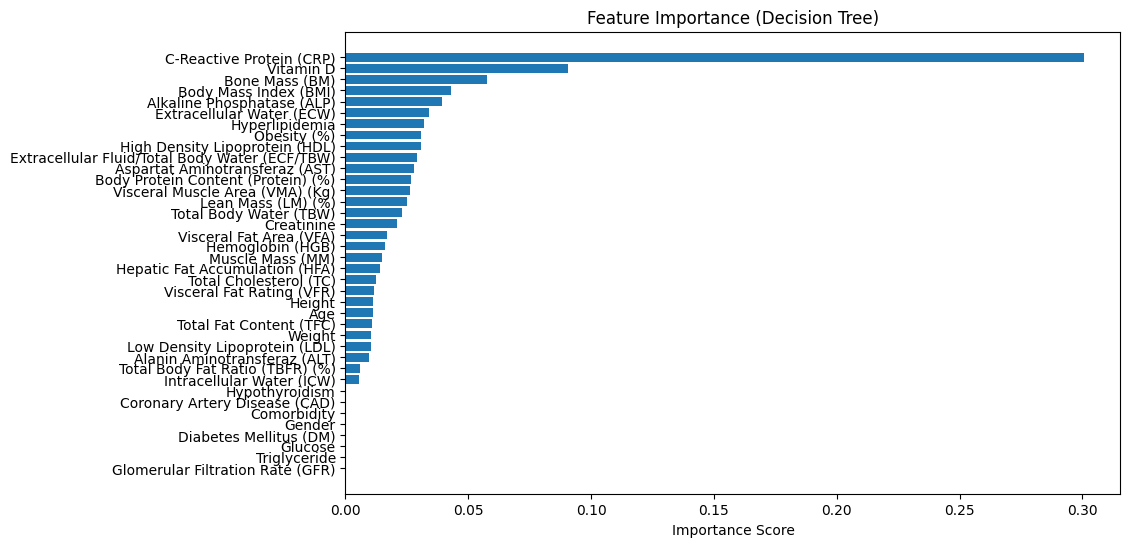


Top Influential Predictors:
['C-Reactive Protein (CRP)', 'Vitamin D', 'Bone Mass (BM)', 'Body Mass Index (BMI)', 'Alkaline Phosphatase (ALP)', 'Extracellular Water (ECW)', 'Hyperlipidemia', 'Obesity (%)', 'High Density Lipoprotein (HDL)', 'Extracellular Fluid/Total Body Water (ECF/TBW)', 'Aspartat Aminotransferaz (AST)', 'Body Protein Content (Protein) (%)', 'Visceral Muscle Area (VMA) (Kg)', 'Lean Mass (LM) (%)', 'Total Body Water (TBW)', 'Creatinine', 'Visceral Fat Area (VFA)', 'Hemoglobin (HGB)', 'Muscle Mass (MM)', 'Hepatic Fat Accumulation (HFA)', 'Total Cholesterol (TC)', 'Visceral Fat Rating (VFR)', 'Height', 'Age', 'Total Fat Content (TFC)', 'Weight', 'Low Density Lipoprotein (LDL)', 'Alanin Aminotransferaz (ALT)', 'Total Body Fat Ratio (TBFR) (%)', 'Intracellular Water (ICW)']
Number of Top Influential Predictors: 30

Optimizing Logistic Regression using User-Defined BFGS...
Starting BFGS optimization...


Converged at iteration 171

BFGS Optimization Summary (first 10 rows):

,Iteration,Cost,Alpha,Grad_Norm
0,0,0.693147,NaN,0.440821
1,1,0.599674,1.0,0.440821
2,2,0.541047,1.0,0.274554
3,3,0.496178,1.0,0.165274
4,4,0.486375,1.0,0.091960
5,5,0.476494,1.0,0.066994
6,6,0.467386,1.0,0.063193
7,7,0.457204,1.0,0.062069
8,8,0.447919,1.0,0.059037
9,9,0.440524,1.0,0.054678



BFGS Optimization Summary (last 10 rows):


,Iteration,Cost,Alpha,Grad_Norm
162,162,0.413844,1.0,0.000034
163,163,0.413844,1.0,0.000033
164,164,0.413844,1.0,0.000032
165,165,0.413844,1.0,0.000031
166,166,0.413844,1.0,0.000029
167,167,0.413844,1.0,0.000027
168,168,0.413844,1.0,0.000023
169,169,0.413844,1.0,0.000020
170,170,0.413844,1.0,0.000018
171,171,0.413844,1.0,0.000012


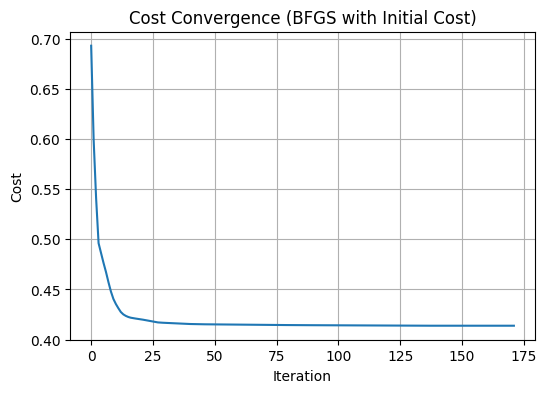


Cost Comparison:


,Metric,Value
0,Initial Cost,0.693147
1,Optimized Cost,0.413844
2,Cost Reduction,0.279304


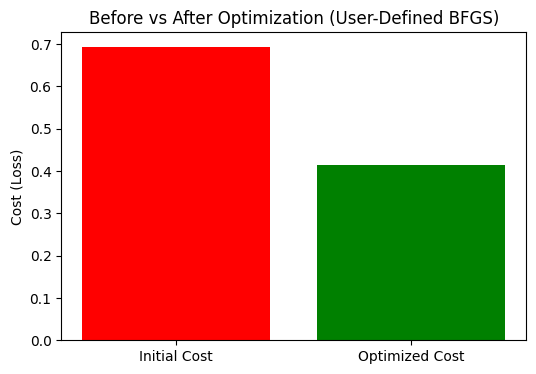


✅ Test Accuracy using Custom BFGS: 85.94%


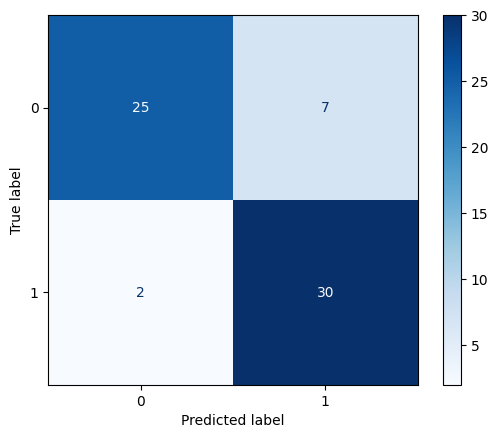

Optimized Weights (w): [-2.02727332  0.81504458  1.73517096  2.10691349 -0.22056934  0.94617558
 -2.23441696 -0.08528783 -0.30560831  0.39152825  1.53775412  0.56869619
 -0.07944537 -0.85393755 -0.82014875 -0.03809811 -0.1931601   0.4985384
  0.66186341 -0.27568773 -0.03429643 -0.17687947  0.51831466 -0.31101973
  1.44449643 -2.82333046  0.04962031 -1.07901656 -1.82153711 -1.59105368]
Optimized Bias (b): -0.612416860276601


In [ ]:
# ====================================================
# 🧠 Logistic Regression using Improved Custom BFGS Optimizer
# ====================================================

# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

# ====================================================
# Load and Inspect Data
# ====================================================
data = pd.read_csv("/content/Gallstone.csv")
data["Gallstone Status"] = [1 if i == 0 else 0 for i in data["Gallstone Status"]]

print("The Gallstone Dataset:")
display(data)

print("Missing values per column:")
print(data.isnull().sum())

# ====================================================
# Separate Features and Target
# ====================================================
X = data.drop('Gallstone Status', axis=1)
y = data['Gallstone Status']

# Encode categorical variables
X = pd.get_dummies(X, drop_first=True)
if y.dtype == 'object':
    y = LabelEncoder().fit_transform(y)

# ====================================================
# Feature Importance using Decision Tree
# ====================================================
tree = DecisionTreeClassifier(random_state=42)
tree.fit(X, y)

importances = pd.DataFrame({
    'feature': X.columns,
    'importance': tree.feature_importances_
}).sort_values(by='importance', ascending=False)

print("\nFeature Importances (Top 10):")
print(importances.head(10))

# Plot all feature importances
plt.figure(figsize=(10, 6))
plt.barh(importances['feature'], importances['importance'])
plt.gca().invert_yaxis()
plt.title("Feature Importance (Decision Tree)")
plt.xlabel("Importance Score")
plt.show()

# Select top influential features
threshold = 0.005
top_features = importances.query("importance >= @threshold")['feature'].tolist()
print("\nTop Influential Predictors:")
print(top_features)
print("Number of Top Influential Predictors:", len(top_features))

# ====================================================
# Train-Test Split
# ====================================================
X = X[top_features]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Ensure numpy arrays
X_train = np.array(X_train)
X_test = np.array(X_test)
y_train = np.array(y_train)
y_test = np.array(y_test)

# ====================================================
# Scale Features
# ====================================================
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ====================================================
# Custom BFGS Logistic Regression (with DataFrame Logging)
# ====================================================
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def cost_function(params, X, y):
    m = X.shape[0]
    if isinstance(y, pd.Series):
        y = y.to_numpy().reshape(-1, 1)
    else:
        y = y.reshape(-1, 1)
    w = params[:-1].reshape(-1, 1)
    b = params[-1]
    z = np.dot(X, w) + b
    h = sigmoid(z)
    cost = -(1/m) * np.sum(y*np.log(h + 1e-12) + (1 - y)*np.log(1 - h + 1e-12))
    return cost

def gradient(params, X, y):
    m = X.shape[0]
    w = params[:-1].reshape(-1, 1)
    b = params[-1]
    z = np.dot(X, w) + b
    h = sigmoid(z)
    dw = (1/m) * np.dot(X.T, (h - y))
    db = (1/m) * np.sum(h - y)
    grad = np.concatenate((dw.flatten(), [db]))
    return grad

def backtracking_line_search(params, pk, X, y, grad, alpha=1.0, rho=0.9, c=1e-4):
    current_cost = cost_function(params, X, y)
    while cost_function(params + alpha * pk, X, y) > current_cost + c * alpha * np.dot(grad, pk):
        alpha *= rho
        if alpha < 1e-10:
            break
    return alpha

def bfgs_logistic_regression(X, y, max_iter=3000, tol=1e-5):
    n = X.shape[1] + 1
    params = np.zeros(n)
    Hk = np.eye(n)
    y = y.reshape(-1, 1)
    cost_history = []
    records = []  # for DataFrame

    print("Starting BFGS optimization...\n")

    # Log initial cost before any updates
    initial_cost = cost_function(params, X, y)
    initial_grad = gradient(params, X, y)
    records.append({
        "Iteration": 0,
        "Cost": float(initial_cost),
        "Alpha": np.nan,
        "Grad_Norm": float(np.linalg.norm(initial_grad))
    })
    cost_history.append(initial_cost)

    # Optimization loop
    for i in range(max_iter):
        grad = gradient(params, X, y).reshape(-1, 1)
        pk = -Hk.dot(grad)

        # Ensure descent direction
        if np.dot(grad.T, pk) > 0:
            pk = -grad

        pk = pk.flatten()
        alpha = backtracking_line_search(params, pk, X, y, grad.flatten())

        new_params = params + alpha * pk
        new_grad = gradient(new_params, X, y).reshape(-1, 1)

        sk = (new_params - params).reshape(-1, 1)
        yk = new_grad - grad

        if np.dot(yk.T, sk) == 0:
            print("Division by zero in BFGS update; stopping.")
            break

        rho_k = 1.0 / np.dot(yk.T, sk)
        I = np.eye(n)
        Vk = I - rho_k * np.dot(sk, yk.T)
        Hk = np.dot(Vk, np.dot(Hk, Vk.T)) + rho_k * np.dot(sk, sk.T)

        params = new_params
        cost = cost_function(params, X, y)
        cost_history.append(cost)

        records.append({
            "Iteration": i + 1,
            "Cost": float(cost),
            "Alpha": float(alpha),
            "Grad_Norm": float(np.linalg.norm(grad))
        })

        if np.linalg.norm(new_grad) < tol:
            print(f"\nConverged at iteration {i+1}")
            break

    # Convert to DataFrame
    results_df = pd.DataFrame(records)

    # Display head and tail
    print("\nBFGS Optimization Summary (first 10 rows):")
    display(results_df.head(10))
    print("\nBFGS Optimization Summary (last 10 rows):")
    display(results_df.tail(10))

    # Plot cost convergence
    plt.figure(figsize=(6, 4))
    plt.plot(results_df["Iteration"], results_df["Cost"])
    plt.title("Cost Convergence (BFGS with Initial Cost)")
    plt.xlabel("Iteration")
    plt.ylabel("Cost")
    plt.grid(True)
    plt.show()

    w_opt = params[:-1].reshape(-1, 1)
    b_opt = params[-1]
    return w_opt, b_opt, results_df

# ====================================================
# Run Custom BFGS Optimization
# ====================================================
print("\nOptimizing Logistic Regression using User-Defined BFGS...")
w_opt, b_opt, results_df = bfgs_logistic_regression(X_train, y_train)

# ====================================================
# Cost Comparison
# ====================================================
initial_params = np.zeros(X_train.shape[1] + 1)
initial_cost = cost_function(initial_params, X_train, y_train)
optimized_params = np.concatenate((w_opt.flatten(), [b_opt]))
optimized_cost = cost_function(optimized_params, X_train, y_train)

cost_comparison = pd.DataFrame({
    "Metric": ["Initial Cost", "Optimized Cost", "Cost Reduction"],
    "Value": [initial_cost, optimized_cost, initial_cost - optimized_cost]
})

print("\nCost Comparison:")
display(cost_comparison)

# Plot cost comparison
plt.figure(figsize=(6, 4))
plt.bar(["Initial Cost", "Optimized Cost"], [initial_cost, optimized_cost], color=["red", "green"])
plt.title("Before vs After Optimization (User-Defined BFGS)")
plt.ylabel("Cost (Loss)")
plt.show()

# ====================================================
# Prediction & Evaluation
# ====================================================
def predict(X, w, b):
    probs = sigmoid(np.dot(X, w) + b)
    preds = (probs >= 0.5).astype(int)
    return preds.flatten()

y_pred = predict(X_test, w_opt, b_opt)
acc = accuracy_score(y_test, y_pred)
print(f"\n✅ Test Accuracy using Custom BFGS: {acc*100:.2f}%")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.show()

print("Optimized Weights (w):", w_opt.flatten())
print("Optimized Bias (b):", b_opt)


The Gallstone Dataset:


,Gallstone Status,Age,Gender,Comorbidity,Coronary Artery Disease (CAD),Hypothyroidism,Hyperlipidemia,Diabetes Mellitus (DM),Height,Weight,...,High Density Lipoprotein (HDL),Triglyceride,Aspartat Aminotransferaz (AST),Alanin Aminotransferaz (ALT),Alkaline Phosphatase (ALP),Creatinine,Glomerular Filtration Rate (GFR),C-Reactive Protein (CRP),Hemoglobin (HGB),Vitamin D
0,1,50,0,0,0,0,0,0,185,92.8,...,40.0,134.0,20.0,22.0,87.0,0.82,112.47,0.0,16.0,33.0
1,1,47,0,1,0,0,0,0,176,94.5,...,43.0,103.0,14.0,13.0,46.0,0.87,107.10,0.0,14.4,25.0
2,1,61,0,0,0,0,0,0,171,91.1,...,43.0,69.0,18.0,14.0,66.0,1.25,65.51,0.0,16.2,30.2
3,1,41,0,0,0,0,0,0,168,67.7,...,59.0,53.0,20.0,12.0,34.0,1.02,94.10,0.0,15.4,35.4
4,1,42,0,0,0,0,0,0,178,89.6,...,30.0,326.0,27.0,54.0,71.0,0.82,112.47,0.0,16.8,40.6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
314,0,49,0,0,0,0,0,0,178,88.8,...,55.0,81.0,28.0,50.0,90.0,0.98,94.50,6.2,16.5,8.3
315,0,31,1,0,0,0,0,0,157,53.4,...,58.0,64.0,24.0,16.0,38.0,0.50,128.50,0.0,12.5,24.0
316,0,58,0,0,0,0,0,0,172,96.6,...,45.0,168.0,21.0,27.0,94.0,1.04,83.23,0.0,15.4,15.7
317,0,37,1,0,0,0,0,0,177,88.4,...,33.0,253.0,40.0,22.0,115.0,1.01,98.23,0.4,16.0,33.3


Missing values per column:
Gallstone Status                                  0
Age                                               0
Gender                                            0
Comorbidity                                       0
Coronary Artery Disease (CAD)                     0
Hypothyroidism                                    0
Hyperlipidemia                                    0
Diabetes Mellitus (DM)                            0
Height                                            0
Weight                                            0
Body Mass Index (BMI)                             0
Total Body Water (TBW)                            0
Extracellular Water (ECW)                         0
Intracellular Water (ICW)                         0
Extracellular Fluid/Total Body Water (ECF/TBW)    0
Total Body Fat Ratio (TBFR) (%)                   0
Lean Mass (LM) (%)                                0
Body Protein Content (Protein) (%)                0
Visceral Fat Rating (VFR)            

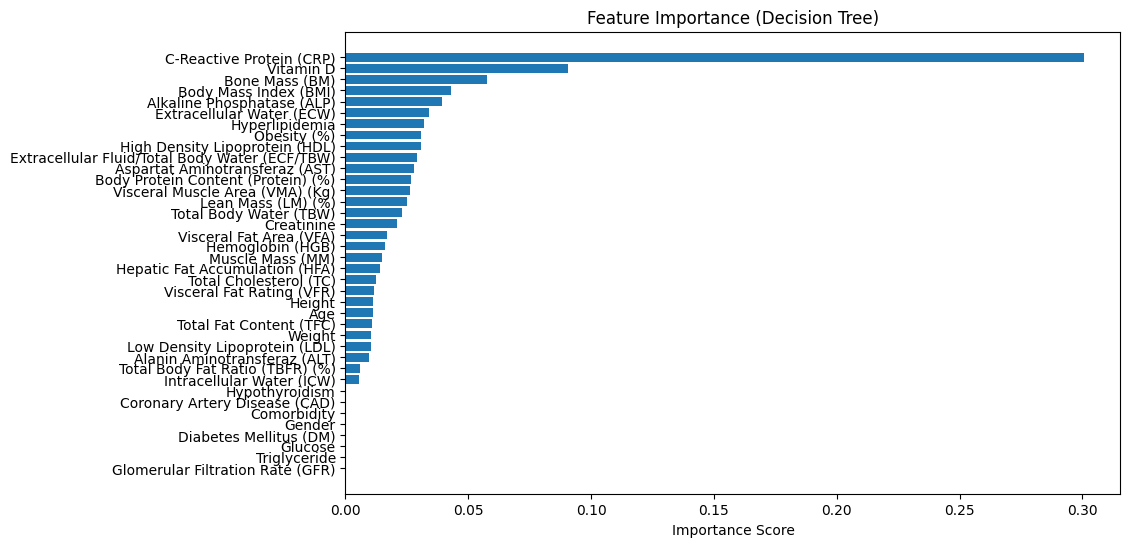


Top Influential Predictors:
['C-Reactive Protein (CRP)', 'Vitamin D', 'Bone Mass (BM)', 'Body Mass Index (BMI)', 'Alkaline Phosphatase (ALP)', 'Extracellular Water (ECW)', 'Hyperlipidemia', 'Obesity (%)', 'High Density Lipoprotein (HDL)', 'Extracellular Fluid/Total Body Water (ECF/TBW)', 'Aspartat Aminotransferaz (AST)', 'Body Protein Content (Protein) (%)', 'Visceral Muscle Area (VMA) (Kg)', 'Lean Mass (LM) (%)', 'Total Body Water (TBW)', 'Creatinine', 'Visceral Fat Area (VFA)', 'Hemoglobin (HGB)', 'Muscle Mass (MM)', 'Hepatic Fat Accumulation (HFA)', 'Total Cholesterol (TC)', 'Visceral Fat Rating (VFR)', 'Height', 'Age', 'Total Fat Content (TFC)', 'Weight', 'Low Density Lipoprotein (LDL)', 'Alanin Aminotransferaz (ALT)', 'Total Body Fat Ratio (TBFR) (%)', 'Intracellular Water (ICW)']
Number of Top Influential Predictors: 30

Optimizing Logistic Regression using Steepest Descent...
Starting Steepest Descent optimization...


✅ Converged at iteration 3263 (ΔCost < 1e-06)

Steepest Des

,Iteration,Cost,Alpha,Grad_Norm
0,0,0.693147,NaN,NaN
1,1,0.674797,0.1,0.440821
2,2,0.660128,0.1,0.392939
3,3,0.648099,0.1,0.354763
4,4,0.637989,0.1,0.324322
5,5,0.629301,0.1,0.299902
6,6,0.621690,0.1,0.280099
7,7,0.614915,0.1,0.263814
8,8,0.608803,0.1,0.250206
9,9,0.603230,0.1,0.238640



Steepest Descent Optimization Summary (last 10 rows):


,Iteration,Cost,Alpha,Grad_Norm
3254,3254,0.416543,0.1,0.003173
3255,3255,0.416542,0.1,0.003172
3256,3256,0.416541,0.1,0.003171
3257,3257,0.416540,0.1,0.003169
3258,3258,0.416539,0.1,0.003168
3259,3259,0.416538,0.1,0.003167
3260,3260,0.416537,0.1,0.003165
3261,3261,0.416536,0.1,0.003164
3262,3262,0.416535,0.1,0.003163
3263,3263,0.416534,0.1,0.003162


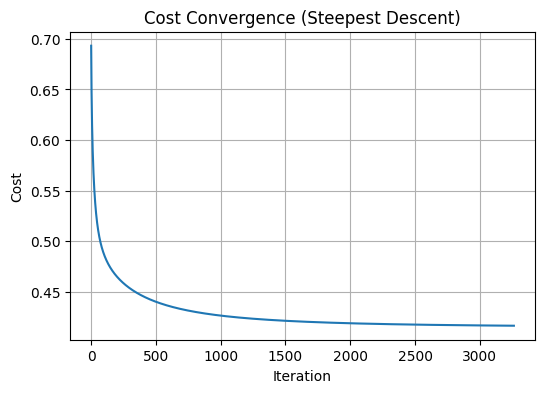


Cost Comparison:


,Metric,Value
0,Initial Cost,0.693147
1,Optimized Cost,0.416534
2,Cost Reduction,0.276613



✅ Test Accuracy using Steepest Descent: 89.06%


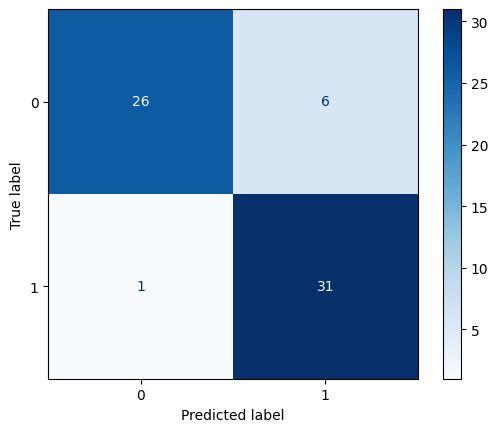

Optimized Weights (w): [-1.94503265  0.77647383  1.47847172  0.81360786 -0.18653548  0.16437189
 -1.28396996 -0.07882014 -0.28644254  0.68410777  1.42693205  0.40493313
 -0.08975756  0.10413678 -0.67192574 -0.04015077 -0.42243605  0.4687907
  0.46030233 -0.25854153 -0.09252581 -0.06960762 -0.26944787 -0.31856009
  0.74616638 -0.06444064  0.12199959 -1.02560462 -1.00049078 -1.43307885]
Optimized Bias (b): -0.44229746404790465


In [ ]:
# ====================================================
# 🧠 Logistic Regression using Custom Steepest Descent Optimizer
# ====================================================

# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score

# ====================================================
# Load and Inspect Data
# ====================================================
data = pd.read_csv("/content/Gallstone.csv")
data[	'Gallstone Status']=[1 if i==0 else 0 for i in data[	'Gallstone Status']]
print("The Gallstone Dataset:")
display(data)
print("Missing values per column:")
print(data.isnull().sum())

# ====================================================
# Separate Features and Target
# ====================================================
X = data.drop('Gallstone Status', axis=1)
y = data['Gallstone Status']

# Encode categorical variables
X = pd.get_dummies(X, drop_first=True)
if y.dtype == 'object':
    y = LabelEncoder().fit_transform(y)

# ====================================================
# Feature Importance using Decision Tree
# ====================================================
tree = DecisionTreeClassifier(random_state=42)
tree.fit(X, y)
importances = pd.DataFrame({
    'feature': X.columns,
    'importance': tree.feature_importances_
}).sort_values(by='importance', ascending=False)
print("\nFeature Importances (Top 10):")
print(importances.head(10))

plt.figure(figsize=(10, 6))
plt.barh(importances['feature'], importances['importance'])
plt.gca().invert_yaxis()
plt.title("Feature Importance (Decision Tree)")
plt.xlabel("Importance Score")
plt.show()

# Select top influential features
threshold = 0.005
top_features = importances.query("importance >= @threshold")['feature'].tolist()
print("\nTop Influential Predictors:")
print(top_features)
print("Number of Top Influential Predictors:", len(top_features))

# ====================================================
# Train-Test Split
# ====================================================
X = X[top_features]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Ensure numpy arrays
X_train = np.array(X_train)
X_test = np.array(X_test)
y_train = np.array(y_train)
y_test = np.array(y_test)

# ====================================================
# Scale Features
# ====================================================
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ====================================================
# Custom Steepest Descent Implementation (like BFGS style)
# ====================================================
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def compute_cost(X, y, w, b):
    if isinstance(y, pd.Series):
        y = y.to_numpy().reshape(-1, 1)
    else:
        y = y.reshape(-1, 1)
    n = X.shape[0]
    z = np.dot(X, w) + b
    y_pred = sigmoid(z)
    cost = -(1/n) * np.sum(y*np.log(y_pred + 1e-15) + (1 - y)*np.log(1 - y_pred + 1e-15))
    return cost

def backtracking_line_search(X, y, w, b, dw, db, grad_norm_sq, alpha=0.1, beta=0.8, c=1e-4):
    cost_current = compute_cost(X, y, w, b)
    while True:
        w_new = w - alpha * dw
        b_new = b - alpha * db
        cost_new = compute_cost(X, y, w_new, b_new)
        if cost_new <= cost_current - c * alpha * grad_norm_sq:
            return alpha
        alpha *= beta
        if alpha < 1e-8:  # Avoid too small steps
            return alpha

def steepest_descent(X, y, iterations=10000, tol=1e-6):
    n, m = X.shape
    if isinstance(y, pd.Series):
        y = y.to_numpy().reshape(-1, 1)
    else:
        y = y.reshape(-1, 1)
    w = np.zeros((m, 1))
    b = 0.0

    prev_cost = float('inf')
    records = []  # For DataFrame logging

    print("Starting Steepest Descent optimization...\n")

    # Log initial cost
    initial_cost = compute_cost(X, y, w, b)
    grad_norm = np.inf
    records.append({
        "Iteration": 0,
        "Cost": float(initial_cost),
        "Alpha": np.nan,
        "Grad_Norm": np.nan
    })

    for i in range(iterations):
        z = np.dot(X, w) + b
        y_pred = sigmoid(z)
        dw = (1/n) * np.dot(X.T, (y_pred - y))
        db = (1/n) * np.sum(y_pred - y)
        grad_norm_sq = np.sum(dw**2) + db**2
        grad_norm = np.sqrt(grad_norm_sq)

        alpha = backtracking_line_search(X, y, w, b, dw, db, grad_norm_sq)
        w -= alpha * dw
        b -= alpha * db
        cost = compute_cost(X, y, w, b)

        records.append({
            "Iteration": i + 1,
            "Cost": float(cost),
            "Alpha": float(alpha),
            "Grad_Norm": float(grad_norm)
        })

        if abs(prev_cost - cost) < tol:
            print(f"\n✅ Converged at iteration {i+1} (ΔCost < {tol})")
            break
        prev_cost = cost

    # Convert results to DataFrame
    results_df = pd.DataFrame(records)

    # Display head and tail
    print("\nSteepest Descent Optimization Summary (first 10 rows):")
    display(results_df.head(10))
    print("\nSteepest Descent Optimization Summary (last 10 rows):")
    display(results_df.tail(10))

    # Plot cost convergence
    plt.figure(figsize=(6, 4))
    plt.plot(results_df["Iteration"], results_df["Cost"])
    plt.title("Cost Convergence (Steepest Descent)")
    plt.xlabel("Iteration")
    plt.ylabel("Cost")
    plt.grid(True)
    plt.show()

    return w, b, results_df

# ====================================================
# Run Steepest Descent Optimization
# ====================================================
print("\nOptimizing Logistic Regression using Steepest Descent...")
w, b, results_df = steepest_descent(X_train, y_train)

# ====================================================
# Cost Comparison
# ====================================================
initial_w = np.zeros((X_train.shape[1], 1))
initial_b = 0.0
initial_cost = compute_cost(X_train, y_train, initial_w, initial_b)
optimized_cost = results_df["Cost"].iloc[-1]

cost_comparison = pd.DataFrame({
    "Metric": ["Initial Cost", "Optimized Cost", "Cost Reduction"],
    "Value": [initial_cost, optimized_cost, initial_cost - optimized_cost]
})

print("\nCost Comparison:")
display(cost_comparison)

# ====================================================
# Prediction & Evaluation
# ====================================================
def predict(X, w, b):
    probs = sigmoid(np.dot(X, w) + b)
    preds = (probs >= 0.5).astype(int)
    return preds.flatten()

y_pred = predict(X_test, w, b)
acc = accuracy_score(y_test, y_pred)
print(f"\n✅ Test Accuracy using Steepest Descent: {acc*100:.2f}%")

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.show()

print("Optimized Weights (w):", w.flatten())
print("Optimized Bias (b):", b)


In [ ]:
from sklearn.linear_model import LogisticRegression
lr=LogisticRegression(penalty=None,tol=0.000001)
lr.fit(X_train,y_train)
y_pred=lr.predict(X_test)
print(accuracy_score(y_test,y_pred))
print(lr.coef_)
print(lr.intercept_)

0.859375
[[-2.02984375  0.81461258  1.73069411  2.05779045 -0.22048241  0.97358418
  -2.17667666 -0.0824409  -0.30339008  0.38464835  1.53833758  0.57473612
  -0.08133042 -0.90123917 -0.81843031 -0.0384737  -0.22131351  0.50034977
   0.65694006 -0.27529574 -0.03597119 -0.16767023  0.49381017 -0.31505085
   1.45864126 -2.79911078  0.05034166 -1.08058746 -1.84054068 -1.57840269]]
[-0.60327991]


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
